# Systematicity probing: dataset + multi-model fine-tuning

Self-contained notebook. Generates a larger, class-balanced artificial-language NLI dataset, fine-tunes six encoders (BERT, RoBERTa, ModernBERT, DeBERTa-base, DeBERTa-v3-base, ALBERT), runs the three systematicity probes (Goodwin et al. 2020), then adds a zero-shot general-purpose LLM as a non-fine-tuned comparison point.

**Before running:** Settings -> Accelerator: GPU. Settings -> Internet: On.


## 1. Write the data-generation source files


In [1]:
%%writefile config.yml
language:
    nouncount: 6
    verbcount: 6
    blockcount: 100
    quantifiers: ["all", "some"]
    adjectives: ["red", "rose", ""]
    Neg: ["not", ""]
    RC: ["that sing", "that hum", ""]
traincells:
    intrablock: 10
    crossblock: 10
    coresets_percell: 1
testcells:
    intrablock: 2              #in-block cells, trained
    trained_crossblock: 2      #crossblock cells, trained
    fliptrained_crossblock: 5   #crossblock cells, untrained, w/ trained mirrors/'twins'
    untrained_crossblock: 10    #crossblock cells, untrained, flip untrained
    wug_count: 20        #crossblock cells XY where neither X nor Y has been crossed in train
    coresets_percell: 1
    neighbour_max_editdistance: 1

Writing config.yml


In [2]:
%%writefile sentence.py
import re
 
template=re.compile(r'(some|all)\s*(feathery|parrot|bird like|slippery|fish like|red|rose)?\s+(aves|anapsida|pig|minor|pumba|wart hog|parrot|macaw|reptilia|caretta)\s*(that|who)?\s*(hum|sing)?\s*(not)?\s*(squawk|chirp|walk|swim|move|breathe|eat|sleep|screech)')
    
class Sentence:

    @staticmethod
    def parse(string):
        #print "Parsing: " + string.strip()
        m=re.match(template, string)
        return Sentence(m.group(1),
                        m.group(2),
                        m.group(3),
                        m.group(4),
                        m.group(5),
                        m.group(6),
                        m.group(7))

    def distance(self, other):
        distance = 0
        #elems = set([self.quantifier, other.quantifier, self.adjective, other.adjective, self.noun, other.noun, self.comp, other.comp, self.relative, other.relative, self.negation, other.negation, self.verb, other.verb])
        #return len(elems) // 7
        if not(self.quantifier==other.quantifier):
                distance = distance + 1
        if not(self.adjective==other.adjective):
                distance = distance + 1
        if not(self.noun==other.noun):
                distance = distance + 1
        if not(self.comp==other.comp):
                distance = distance + 1
        if not(self.relative==other.relative):
                distance = distance + 1
        if not(self.negation==other.negation):
                distance = distance + 1
        if not(self.verb==other.verb):
                distance = distance + 1
        return(distance)


    def diff(self, other):
        diff = []
        if not(self.quantifier==other.quantifier):
                diff = [self.quantifier, other.quantifier]
        if not(self.adjective==other.adjective):
                diff = [self.adjective, other.adjective]
        if not(self.noun==other.noun):
                diff = [self.noun, other.noun]
        if not(self.relative==other.relative):
                diff = [self.comp+' ' +self.relative, other.comp+' ' +other.relative]
        if not(self.negation==other.negation):
                diff = [self.negation, other.negation]
        if not(self.verb==other.verb):
                diff = [self.verb, other.verb]
        return(diff)
        
    def __init__(self, quantifier, adjective, noun, comp, relative, negation, verb):
        self.quantifier = quantifier
        self.adjective = adjective
        self.noun = noun
        self.comp=comp
        self.relative=relative
        self.negation=negation
        self.verb=verb

    def __str__(self):
        return("(S (Q "+ str(self.quantifier) + ")" +
        "(A " + str(self.adjective) + ")" +
        "(N " + str(self.noun) + ")" +
        "(C " + str(self.comp) + ")" +
        "(R " + str(self.relative) + ")" +
        "(Neg " + str(self.negation) + ")" +
        "(V " + str(self.verb) + "))")


Writing sentence.py


In [3]:
%%writefile item.py
from sentence import Sentence


class Item:
    """
    A premise/hypothesis pair plus its gold natural-logic relation.

    Fixes vs. the originally uploaded file:
    - Added `string()`. The rest of the pipeline (coresetgenerators.py,
      utils.myprint) keys dictionaries on `item.string()`, but the
      uploaded item.py never defined it.
    - `label` is now optional (defaults to None). In the original repo
      this field holds a *model's predicted* relation, filled in later
      during evaluation -- it isn't known at dataset generation time,
      so it shouldn't be a required constructor arg.
    - Fixed `csv()`, which was missing a `return`.
    """

    @staticmethod
    def parse_training_item(string):
        fields = string.strip().split('\t')
        prem = Sentence.parse(fields[1])
        hyp = Sentence.parse(fields[2])
        return Item(prem, hyp, fields[0], None, False)

    def __init__(self, premise, hypothesis, correct, label=None, test=False):
        self.premise = premise
        self.hypothesis = hypothesis
        self.correct = correct   # gold natural-logic relation
        self.label = label       # model prediction (filled in later, if at all)
        self.test = test

    def string(self):
        """Unique string key for this premise/hypothesis pair (used for
        de-duplication and as a dict key)."""
        return str(self.premise) + "," + str(self.hypothesis)

    def hash_key(self):
        return str(self.premise) + str(self.hypothesis) + str(self.correct) + str(self.label) + str(self.test)

    def get_premise(self):
        return self.premise

    def get_hypothesis(self):
        return self.hypothesis

    def distance(self, other):
        return (self.premise.distance(other.premise) +
                self.hypothesis.distance(other.hypothesis))

    def diff(self, other):
        if not (Sentence.diff(self.premise, other.premise) == []):
            return (Sentence.diff(self.premise, other.premise), "premise")
        if not (Sentence.diff(self.hypothesis, other.hypothesis) == []):
            return (Sentence.diff(self.hypothesis, other.hypothesis), "hypothesis")
        return ([], None)

    def is_target(self):
        return ((self.premise.adjective == "rose" or
                 self.hypothesis.adjective == "rose") and
                (self.premise.noun == "minor" or
                 self.hypothesis.noun == "minor") and
                (self.premise.verb == "swim" or
                 self.hypothesis.verb == "swim"))

    def csv(self):
        return (str(self.premise) + "," + str(self.hypothesis) + "," +
                str(self.correct) + "," + str(self.label) + "," + str(self.test))


Writing item.py


In [4]:
%%writefile utils.py
#!/usr/bin/env python
#encoding: UTF-8

from itertools import product
from operator import itemgetter
from collections import defaultdict
from collections import Counter
from sentence import Sentence
from item import Item
import random
import pdb
import os
import re


#Interpretation function:
def interpret(p, h):
    FOR = "<"
    REV = ">"
    NEG = "^"
    ALT = "|"
    COV = "v"
    EQ = "="
    INDY = "#"
    UNK = "?"


    JOINTABLE = {  # Replaced UNK with INDY to match Emy's table
        EQ:  {EQ: EQ,  FOR: FOR, REV: REV, NEG: NEG,  ALT: ALT, COV: COV, INDY: INDY, INDY: INDY},
        FOR: {EQ: FOR, FOR: FOR, REV: INDY, NEG: ALT,  ALT: ALT, COV: INDY, INDY: INDY,  INDY: INDY},
        REV: {EQ: REV, FOR: INDY, REV: REV, NEG: COV,  ALT: INDY, COV: COV, INDY: INDY,  INDY: INDY},
        NEG: {EQ: NEG, FOR: COV, REV: ALT, NEG: EQ,   ALT: REV, COV: FOR, INDY: INDY, INDY: INDY},
        ALT: {EQ: ALT, FOR: INDY, REV: ALT, NEG: FOR,  ALT: INDY, COV: FOR, INDY: INDY,  INDY: INDY},
        COV: {EQ: COV, FOR: COV, REV: INDY, NEG: REV,  ALT: REV, COV: INDY, INDY: INDY,  INDY: INDY},
        INDY: {EQ: INDY, FOR: INDY, REV: INDY, NEG: INDY, ALT: INDY, COV: INDY, INDY: INDY,  INDY: INDY},
        UNK: {EQ: UNK, FOR: UNK, REV: UNK, NEG: UNK,  ALT: UNK, COV: UNK, INDY: UNK,  UNK: UNK},
    }

    #Set up vocabulary, Lexical relationships:

    relatives = ['', 'that hum', 'that sing']
    relatives_matrix = [
        [EQ,    REV,    REV,    REV], #''
        [FOR,   EQ,     REV,    REV],   #'that hum'
        [FOR,   FOR,    EQ,     REV],   #'that sing'
        [FOR,   FOR,    FOR,    EQ]#'that solo'
    ]

    dets = ['all', 'some']
    det_matrix = [
        # all   not_all some    no      most    not_most two    lt_two  three
        # lt_three
        [EQ,    NEG,    FOR,    ALT,    FOR,    ALT,     INDY,  INDY,   INDY,   INDY],  # all
        [NEG,   EQ,     COV,    REV,    COV,    REV,     INDY,  INDY,   INDY,   INDY],  # not_all
        [REV,   COV,    EQ,     NEG,    REV,    COV,     REV,   COV,    REV,    COV],  # some
        [ALT,   FOR,    NEG,    EQ,     ALT,    FOR,     ALT,   FOR,    ALT,    FOR],  # no
        [REV,   COV,    FOR,    ALT,    EQ,     NEG,     INDY,  INDY,   INDY,   INDY],  # most
        [ALT,   FOR,    COV,    REV,    NEG,    EQ,      INDY,  INDY,   INDY,   INDY],  # not_most
        [INDY,  INDY,   FOR,    ALT,    INDY,   INDY,    EQ,    NEG,    REV,    COV],  # two
        [INDY,  INDY,   COV,    REV,    INDY,   INDY,    NEG,   EQ,     ALT,    FOR],  # lt_two
        [INDY,  INDY,   FOR,    ALT,    INDY,   INDY,    FOR,   ALT,    EQ,     NEG],  # three
        [INDY,  INDY,   COV,    REV,    INDY,   INDY,    COV,   REV,    NEG,    EQ]    # lt_three
        ]
    negs = ['', 'not']
    negs_matrix = [
        #''     not
        [EQ,    2],     #'' in first position
        [1, 3]       #"not" first position
        ]

    adjectives = ['', 'rose', 'red']

    lexicon = {
        ('', ''):       EQ,
        ('', 'rose'):   REV,
        ('rose', ''):   FOR,
        ('rose', 'rose'): EQ,
        ('', 'red'):    REV,
        ('red', ''):    FOR,
        ('red', 'red'): EQ,
        ('rose', 'red'): FOR,
        ('red', 'rose'): REV
        }

    for i, j in product(range(len(negs)), range(len(negs))):
        lexicon[(negs[i], negs[j])] = negs_matrix[i][j]

    for i, j in product(range(len(dets)), range(len(dets))):
        lexicon[(dets[i], dets[j])] = det_matrix[i][j]

    for i, j in product(range(len(relatives)), range(len(relatives))):
        lexicon[(relatives[i], relatives[j])] = relatives_matrix[i][j]


    #decompose tree
    det = (p.quantifier, h.quantifier)
    adj = (p.adjective, h.adjective)
    noun = (p.noun, h.noun)
    relative = (p.relative, h.relative)
    neg = (p.negation, h.negation)
    verb = (p.verb, h.verb)

    #get noun relations
    if p.noun[-1] == h.noun[-1]:
        nounrelation = EQ
    elif p.noun[-1] > h.noun[-1]:
        nounrelation = FOR
    elif p.noun[-1] < h.noun[-1]:
        nounrelation = REV
    else:
        print("Could not find relation between nouns: " + str(noun))

    if p.verb[-1] == h.verb[-1]:
        verbrelation = EQ
    elif p.verb[-1] > h.verb[-1]:
        verbrelation = FOR
    elif p.verb[-1] < h.verb[-1]:
        verbrelation = REV
    else:
        print("Could not find relation between verbs: " + str(verb))


    #define the relationship between NPs
    if lexicon.get(relative) == EQ:
        if nounrelation == EQ:
            nprelation = EQ
        elif nounrelation == FOR:
            nprelation = FOR
        elif nounrelation == REV:
            nprelation = REV
        elif nounrelation == INDY:
            nprelation = INDY
        else:
            print("Could not find relation between Nouns: " + str(noun))

    elif lexicon.get(relative) == FOR:
        if nounrelation == EQ:
            nprelation = FOR
        elif nounrelation == FOR:
            nprelation = FOR
        elif nounrelation == REV:
            nprelation = INDY
        else:
            print("Could not find relation between Nouns: " + str(noun))

    elif lexicon.get(relative) == REV:
        if nounrelation == EQ:
            nprelation = REV
        elif nounrelation == FOR:
            nprelation = INDY
        elif nounrelation == REV:
            nprelation = REV
        else:
            print("Could not find relation between Nouns: " + str(noun))
    else:
        print("Could not find relation between Relative Clauses: " + str(rc))

    #define the relationship between APs
    if lexicon.get(adj) == EQ:
        if nprelation == EQ:
            aprelation = EQ
        elif nprelation == FOR:
            aprelation = FOR
        elif nprelation == REV:
            aprelation = REV
        elif nprelation == INDY:
            aprelation = INDY
        else:
            print("Can't find AP relation: " + str(adj))
    elif lexicon.get(adj) == FOR:
        if nprelation == EQ:
            aprelation = FOR
        elif nprelation == FOR:
            aprelation = FOR
        elif nprelation == REV:
            aprelation = INDY
        elif nprelation == INDY:
            aprelation = INDY
        else:
            print("Can't find AP relation: " + str(adj))
    elif lexicon.get(adj) == REV:
        if nprelation == EQ:
            aprelation = REV
        elif nprelation == FOR:
            aprelation = INDY
        elif nprelation == REV:
            aprelation = REV
        elif nprelation == INDY:
            aprelation = INDY
        else:
            print("Can't find AP relation: " + str(adj))
    else:
        print("help: nounmod?")

#define the relationship between VPS

    if lexicon.get(neg) == EQ:          #nonegation
        if verbrelation == FOR:
            vprelation = FOR
        elif verbrelation == REV:
            vprelation = REV
        elif verbrelation == ALT:
            vprelation = ALT
        elif verbrelation == EQ:
            vprelation = EQ
        else:
            print("can't find verb relation: " + str(verb))
    elif lexicon.get(neg) == 3:          #neg in both sentences
        if verbrelation == FOR:
            vprelation = REV
        elif verbrelation == REV:
            vprelation = FOR
        elif verbrelation == ALT:
            vprelation = COV
        elif verbrelation == EQ:
            vprelation = EQ
        else:
            print("can't find verb relation: " + str(verb))

    elif lexicon.get(neg) == 1:          #neg in position 1
        if verbrelation == FOR:
            vprelation = COV
        elif verbrelation == REV:
            vprelation = ALT
        elif verbrelation == ALT:
            vprelation = REV
        elif verbrelation == EQ:
            vprelation = NEG
        else:
            print("can't find verb relation: " + str(verb))
    elif lexicon.get(neg) == 2:          #neg in position 2
        if verbrelation == FOR:
            vprelation = ALT
        elif verbrelation == REV:
            vprelation = COV
        elif verbrelation == ALT:
            vprelation = FOR
        elif verbrelation == EQ:
            vprelation = NEG
        else:
            print("can't find verb relation: " + str(verb))
    else:
        print("can't find negation relation: " + str(neg))

#define the relationship between Sentences

    if det == ("some", "some"):
        if aprelation == EQ:
            if vprelation == EQ:
                return EQ
            if vprelation == FOR:
                return FOR
            if vprelation == REV:
                return REV
            if vprelation == NEG:
                return COV
            if vprelation == ALT:
                return INDY
            if vprelation == COV:
                return COV
            if vprelation == INDY:
                return INDY

        elif aprelation == FOR:
            if vprelation == EQ:
                return FOR
            if vprelation == FOR:
                return FOR
            if vprelation == REV:
                return INDY
            if vprelation == NEG:
                return COV
            if vprelation == COV:
                return COV
            if vprelation == ALT:
                return INDY
            if vprelation == INDY:
                return INDY
            else:
                "Np: FOR; VP: ?"

        elif aprelation == REV:
            if vprelation == EQ:
                return REV
            if vprelation == FOR:
                return INDY
            if vprelation == REV:
                return REV
            if vprelation == NEG:
                return COV
            if vprelation == COV:
                return COV
            if vprelation == ALT:
                return INDY ##used to be cov?
            if vprelation == INDY:
                return INDY
            else:
                "NP: FOR; VP: ?"

        elif aprelation == INDY:
            if vprelation == EQ:
                return INDY
            if vprelation == FOR:
                return INDY
            if vprelation == REV:
                return INDY
            if vprelation == NEG:
                return INDY
            if vprelation == COV:
                return INDY
            if vprelation == ALT:
                return INDY
            if vprelation == INDY:
                return INDY
            else:
                "NP: FOR; VP: ?"

    elif det == ("some", "all"):
        if aprelation == FOR:
            if vprelation == EQ:
                return REV
            if vprelation == FOR:
                return INDY
            if vprelation == REV:
                return REV
            if vprelation == NEG:
                return ALT
            if vprelation == ALT:
                return ALT
            if vprelation == COV:
                return INDY
            if vprelation == INDY:
                return INDY

        elif aprelation == REV:
            if vprelation == EQ:
                return REV
            if vprelation == FOR:
                return INDY
            if vprelation == REV:
                return REV
            if vprelation == NEG:
                return COV
            if vprelation == ALT:
                return INDY
            if vprelation == COV:
                return COV ##changed from INDY
            if vprelation == INDY:
                return INDY

        elif aprelation == EQ:
            if vprelation == EQ:
                return REV
            if vprelation == FOR:
                return INDY
            if vprelation == REV:
                return REV
            if vprelation == NEG:
                return NEG
            if vprelation == ALT:
                return ALT
            if vprelation == COV:
                return NEG
            if vprelation == INDY:
                return INDY

        elif aprelation == INDY:
            if vprelation == EQ:
                return INDY
            if vprelation == FOR:
                return INDY
            if vprelation == REV:
                return INDY
            if vprelation == NEG:
                return INDY
            if vprelation == ALT:
                return INDY
            if vprelation == COV:
                return INDY
            if vprelation == INDY:
                return INDY

    elif det == ("all", "some"):
        if aprelation == FOR:
            if vprelation == EQ:
                return FOR
            if vprelation == FOR:
                return FOR
            if vprelation == REV:
                return INDY
            if vprelation == NEG:
                return COV
            if vprelation == ALT:
                return INDY
            if vprelation == COV:
                return COV ##changed from INDY
            if vprelation == INDY:
                return INDY

        elif aprelation == REV:
            if vprelation == EQ:
                return FOR
            if vprelation == FOR:
                return FOR
            if vprelation == REV:
                return INDY
            if vprelation == NEG:
                return ALT
            if vprelation == ALT:
                return ALT
            if vprelation == COV:
                return INDY
            if vprelation == INDY:
                return INDY

        elif aprelation == EQ:
            if vprelation == EQ:
                return FOR
            if vprelation == FOR:
                return FOR
            if vprelation == REV:
                return INDY
            if vprelation == NEG:
                return NEG
            if vprelation == ALT:
                return ALT
            if vprelation == COV:
                return COV ##
            if vprelation == INDY:
                return INDY

        elif aprelation == INDY:
            if vprelation == EQ:
                return INDY
            if vprelation == FOR:
                return INDY
            if vprelation == REV:
                return INDY
            if vprelation == NEG:
                return INDY
            if vprelation == ALT:
                return INDY
            if vprelation == COV:
                return INDY
            if vprelation == INDY:
                return INDY
    elif det == ("all", "all"):
        if aprelation == EQ:
            if vprelation == EQ:
                return EQ
            elif vprelation == FOR:
                return FOR
            elif vprelation == REV:
                return REV
            elif vprelation == NEG:
                return ALT
            elif vprelation == ALT:
                return ALT
            elif vprelation == COV:
                return INDY
            elif vprelation == INDY:
                return INDY
            elif vprelation == UNK:
                print('warning: unclear relation')
        elif aprelation == FOR:
            if vprelation == EQ:
                return REV
            elif vprelation == FOR:
                return INDY
            elif vprelation == REV:
                return REV
            elif vprelation == NEG:
                return ALT
            elif vprelation == ALT:
                return ALT
            elif vprelation == COV:
                return INDY
            elif vprelation == INDY:
                return INDY
            elif vprelation == UNK:
                print('warning: unclear relation')
        elif aprelation == REV:
            if vprelation == EQ:
                return FOR
            elif vprelation == FOR:
                return FOR
            elif vprelation == REV:
                return INDY
            elif vprelation == NEG:
                return ALT
            elif vprelation == ALT:
                return ALT
            elif vprelation == COV:
                return INDY
            elif vprelation == INDY:
                return INDY
            elif vprelation == UNK:
                print('warning: unclear relation')
        elif aprelation == INDY:
            if vprelation == EQ:
                return INDY
            elif vprelation == FOR:
                return INDY
            elif vprelation == REV:
                return INDY
            elif vprelation == NEG:
                return INDY
            elif vprelation == ALT:
                return INDY
            elif vprelation == COV:
                return INDY
            elif vprelation == INDY:
                return INDY
            elif vprelation == UNK:
                print('warning: unclear relation')


def sample_item(quantifiers, adjectives, Psub, Hsub, RC, Neg, Pverb, Hverb, test):
    premise = Sentence(random.choice(quantifiers), random.choice(adjectives), Psub, "", random.choice(RC), random.choice(Neg), Pverb)
    hypothesis = Sentence(random.choice(quantifiers), random.choice(adjectives), Hsub, "",  random.choice(RC), random.choice(Neg), Hverb)
    item = Item(premise, hypothesis, interpret(premise, hypothesis), test)
    return(item)


def split_sents(recs, path, dt):
    s1 = []
    s2 = []
    labels = []
    for rec in recs:
        a,b,c = rec.split('\t')
        s1.append()
        s2.append(re.sub(' +', ' ', c.replace('(', '').replace(')','')))
        labels.append(a)
    with open(os.path.join(path, 's1.{}'.format(dt)),'w') as fp:
        fp.write('\n'.join(s1))
    with open(os.path.join(path, 's2.{}'.format(dt)),'w') as fp:
        fp.write('\n'.join(s2))
    with open(os.path.join(path, 'labels.{}'.format(dt)),'w') as fp:
        fp.write('\n'.join(labels))

def reformat(sent):
    return ' '.join(filter(None, [p.split(' ')[-1] for p in sent.split(')')]))

def myprint(mydict, stepnumber, loc='/steps/', split=0.8):
    save_path = os.path.join(loc, 'step_{}'.format(stepnumber))
    if not os.path.exists(save_path):
        os.mkdir(save_path)
    # outfile = open("all_data.csv", "w")
    outfile = open(os.path.join(save_path, "all_data.csv"),'w')
    outfile.write("item,label,ID,test,type,nounblock,verbblock,stepadded,neighbourlist,\n")#,MinTrainingLabels\n")
    outfile_id = 0
    clean_data = {
            'train': {'s1': [],'s2': [],'labels': [], 'ids': []},
            'test': {'s1': [],'s2': [],'labels': [], 'ids': []},
            'dev': {'s1': [],'s2': [],'labels': [], 'ids': []}
    }
    for key in mydict:
        outfile.write(key + ',' +
            str(mydict[key][0]) + ',' +
            str(mydict[key][1]) + ',' +
            str(mydict[key][2]) + ',' +
            str(mydict[key][3]) + ',' +
            str(mydict[key][4]) + ',' +
            str(mydict[key][5]) + ',' +
            str(mydict[key][6]) + ',' +
            str(mydict[key][7]) + "\n")
        outfile.flush()
        hyp_prem = key.split(',')
    #     if mydict[key][2] == 1:
    #         clean_data['test']['s1'].append(reformat(hyp_prem[0]))
    #         clean_data['test']['s2'].append(reformat(hyp_prem[1]))
    #         clean_data['test']['labels'].append(reformat(mydict[key][0]))
    #         clean_data['test']['ids'].append(str(outfile_id))
    #     elif mydict[key][2] == 0:
    #         clean_data['train']['s1'].append(reformat(hyp_prem[0]))
    #         clean_data['train']['s2'].append(reformat(hyp_prem[1]))
    #         clean_data['train']['labels'].append(reformat(mydict[key][0]))
    #         clean_data['train']['ids'].append(str(outfile_id))
    #     else:
    #         clean_data['dev']['s1'].append(reformat(hyp_prem[0]))
    #         clean_data['dev']['s2'].append(reformat(hyp_prem[1]))
    #         clean_data['dev']['labels'].append(reformat(mydict[key][0]))
    #         clean_data['dev']['ids'].append(str(outfile_id))
    #     outfile_id += 1

    # for dt, vals in clean_data.items():
    #     for flt, fltv in vals.items():
    #         with open(os.path.join(save_path, "{}.{}".format(flt, dt)),
    #                                                             'w') as fp:
    #             print("Writing {}.{} - {} lines".format(flt, dt, len(fltv)))
    #             fp.write('\n'.join(fltv))
    print("saving done.")


Writing utils.py


In [5]:
%%writefile lang_config.py
"""
Loads the closed-class vocabulary from config.yml (quantifiers, adjectives,
negation, relative clauses) -- this part is unchanged / reused as-is from
the original repo. Open-class vocab (nouns/verbs) is generated
programmatically per block, following the block-structure idea from
Goodwin et al. (2020), section 5.4: each block gets its own noun/verb
taxonomy and blocks never mix.
"""
import yaml

with open("config.yml") as f:
    _cfg = yaml.safe_load(f)

QUANTIFIERS = _cfg["language"]["quantifiers"]      # ["all", "some"]
ADJECTIVES = _cfg["language"]["adjectives"]         # ["red", "rose", ""]
NEG = _cfg["language"]["Neg"]                       # ["not", ""]
RC = _cfg["language"]["RC"]                         # ["that sing", "that hum", ""]

WORDS_PER_BLOCK = 7  # matches the original hard-coded range(0, 7) in coresetgenerators.py
NOVEL_INDEX = 3       # the "held out" word within an otherwise-known block


def block_vocab(block_id, prefix_n="N", prefix_v="V"):
    """Nouns/verbs for one block, e.g. block_id=2 -> N2.0 .. N2.6 / V2.0 .. V2.6"""
    nouns = [f"{prefix_n}{block_id}.{i}" for i in range(WORDS_PER_BLOCK)]
    verbs = [f"{prefix_v}{block_id}.{i}" for i in range(WORDS_PER_BLOCK)]
    return nouns, verbs


def background_vocab(block_id, prefix_n="N", prefix_v="V"):
    """The 6 words per block that ARE allowed in training (excludes NOVEL_INDEX)."""
    nouns, verbs = block_vocab(block_id, prefix_n, prefix_v)
    return ([w for i, w in enumerate(nouns) if i != NOVEL_INDEX],
            [w for i, w in enumerate(verbs) if i != NOVEL_INDEX])


Writing lang_config.py


In [6]:
%%writefile render.py
def surface(sentence):
    """Render a Sentence in natural word order, per Table 2 of the paper:
    quantifier, adjective, noun, relative-clause/postmodifier, negation, verb.
    Empty slots are skipped."""
    parts = [sentence.quantifier, sentence.adjective, sentence.noun,
             sentence.relative, sentence.negation, sentence.verb]
    return " ".join(p for p in parts if p)


Writing render.py


In [7]:
%%writefile generate.py
"""Artificial-language NLI generator (Goodwin, Sinha & O'Donnell 2020)."""
import csv
import random
import itertools
from pathlib import Path
from collections import Counter

from sentence import Sentence
from item import Item
from utils import interpret
from lang_config import QUANTIFIERS, ADJECTIVES, NEG, RC, background_vocab, block_vocab
from render import surface

random.seed(1234)

# ---- scale ----
KNOWN_BLOCKS = 8
JABBERWOCKY_BLOCKS = 3
TRAIN_PER_BLOCK = 1200
HOLDOUT_PER_BLOCK = 200
JABBERWOCKY_PER_BLOCK = 250
DEV_FRACTION = 0.2
OUT_DIR = Path("data")

# ---- class balance ----
MIN_TRAIN_PER_CLASS = 300   # top up rare relations to this count
MAX_TRAIN_PER_CLASS = 400   # cap over-represented relations (mainly '#') to this count
TOPUP_MAX_ATTEMPTS = 2_000_000


def fill_sentence(noun, verb):
    return Sentence(
        random.choice(QUANTIFIERS), random.choice(ADJECTIVES), noun,
        "", random.choice(RC), random.choice(NEG), verb,
    )


def make_item(n1, n2, v1, v2, test):
    premise = fill_sentence(n1, v1)
    hypothesis = fill_sentence(n2, v2)
    correct = interpret(premise, hypothesis)
    return Item(premise, hypothesis, correct, None, test)


def sample_unique_combos(nouns, verbs, k, exclude=frozenset()):
    universe = list(itertools.product(nouns, nouns, verbs, verbs))
    random.shuffle(universe)
    out = []
    for combo in universe:
        if combo in exclude:
            continue
        out.append(combo)
        if len(out) == k:
            break
    return out


def cap_common_classes(rows, max_per_class=MAX_TRAIN_PER_CLASS, seed=1234):
    """Downsamples any relation above max_per_class so no single class
    (usually '#', independence) can dominate the training set."""
    rng = random.Random(seed)
    by_label = {}
    for r in rows:
        by_label.setdefault(r["relation"], []).append(r)
    out = []
    for label, group in by_label.items():
        out += rng.sample(group, max_per_class) if len(group) > max_per_class else group
    return out


def top_up_rare_classes(existing_rows, block_vocabs, min_per_class=MIN_TRAIN_PER_CLASS,
                         max_attempts=TOPUP_MAX_ATTEMPTS):
    """Rejection-samples fresh items to bring every relation up to min_per_class.
    '=' and '^' are structurally rare under uniform random filling, so class
    weighting alone can't fix them -- this generates genuinely new, distinct
    examples instead of bootstrapping the same handful of rows."""
    counts = Counter(r["relation"] for r in existing_rows)
    needed = {lbl: max(0, min_per_class - counts.get(lbl, 0)) for lbl in
              ["=", "<", ">", "^", "|", "v", "#"]}
    extra_rows = []
    attempts = 0
    while any(v > 0 for v in needed.values()) and attempts < max_attempts:
        attempts += 1
        block_id, nouns, verbs = random.choice(block_vocabs)
        n1, n2 = random.choice(nouns), random.choice(nouns)
        v1, v2 = random.choice(verbs), random.choice(verbs)
        item = make_item(n1, n2, v1, v2, test=0)
        if needed.get(item.correct, 0) > 0:
            extra_rows += items_to_rows([item], block_id, "train")
            needed[item.correct] -= 1
    still_missing = {k: v for k, v in needed.items() if v > 0}
    if still_missing:
        print(f"[warning] could not reach min_train_per_class={min_per_class} for "
              f"{still_missing} after {attempts} attempts -- structurally very rare for this vocab.")
    else:
        print(f"[top-up] reached min_train_per_class={min_per_class} for all relations "
              f"in {attempts} attempts (+{len(extra_rows)} extra rows)")
    return extra_rows


RELATION_NAMES = {
    "=": "equivalence", "<": "forward_entailment", ">": "reverse_entailment",
    "^": "negation", "|": "alternation", "v": "cover", "#": "independence",
}


def items_to_rows(items, block_id, split):
    rows = []
    for it in items:
        rows.append({
            "premise_text": surface(it.premise), "hypothesis_text": surface(it.hypothesis),
            "premise": str(it.premise), "hypothesis": str(it.hypothesis),
            "relation": it.correct, "relation_name": RELATION_NAMES.get(it.correct, it.correct),
            "block": block_id, "split": split,
        })
    return rows


def write_csv(rows, path):
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=["premise_text", "hypothesis_text", "premise",
                                                "hypothesis", "relation", "relation_name", "block", "split"])
        writer.writeheader()
        writer.writerows(rows)
    print(f"wrote {len(rows):5d} rows -> {path}")


def main():
    train_rows, dev_rows, holdout_rows, jab_rows = [], [], [], []
    known_block_vocabs = []

    for b in range(KNOWN_BLOCKS):
        nouns, verbs = background_vocab(b)
        known_block_vocabs.append((b, nouns, verbs))

        train_combos = sample_unique_combos(nouns, verbs, TRAIN_PER_BLOCK)
        holdout_combos = sample_unique_combos(nouns, verbs, HOLDOUT_PER_BLOCK, exclude=set(train_combos))

        n_dev = int(len(train_combos) * DEV_FRACTION)
        dev_combos, train_combos = train_combos[:n_dev], train_combos[n_dev:]

        train_rows += items_to_rows([make_item(*c, test=0) for c in train_combos], b, "train")
        dev_rows += items_to_rows([make_item(*c, test=2) for c in dev_combos], b, "dev")
        holdout_rows += items_to_rows([make_item(*c, test=1) for c in holdout_combos], b, "holdout")

    print("relation distribution (raw train, before cap/top-up):", Counter(r["relation"] for r in train_rows))
    train_rows = cap_common_classes(train_rows)
    train_rows += top_up_rare_classes(train_rows, known_block_vocabs)

    for jb in range(KNOWN_BLOCKS, KNOWN_BLOCKS + JABBERWOCKY_BLOCKS):
        nouns, verbs = block_vocab(jb)
        combos = sample_unique_combos(nouns, verbs, JABBERWOCKY_PER_BLOCK)
        jab_rows += items_to_rows([make_item(*c, test=1) for c in combos], jb, "jabberwocky")

    write_csv(train_rows, OUT_DIR / "train.csv")
    write_csv(dev_rows, OUT_DIR / "dev.csv")
    write_csv(holdout_rows, OUT_DIR / "holdout.csv")
    write_csv(jab_rows, OUT_DIR / "jabberwocky.csv")

    print("\nrelation distribution (final train):", Counter(r["relation"] for r in train_rows))
    print("relation distribution (jabberwocky):", Counter(r["relation"] for r in jab_rows))


if __name__ == "__main__":
    main()


Writing generate.py


In [8]:
%%writefile probes.py
"""
Builds the three systematicity probes from Goodwin et al. (2020), section 7,
on top of the jabberwocky test set produced by generate.py.

Each probe outputs pairs of test items sharing a `pair_id`, so that after
you get model predictions on both sides you can check the model's
*consistency* rather than just raw accuracy. That comparison (not done
here) is where the actual "is this model systematic?" analysis happens --
see the docstring at the bottom of this file for how to use the output.

1. known_word_perturbation.csv
   Start from a jabberwocky item, swap ONE closed-class word
   (quantifier/negation/relative-clause) in the premise for a different
   value, and recompute the gold relation. A systematic model should
   change its prediction exactly the way the gold label changes; if it
   doesn't, the closed-class word isn't being treated consistently.

2. identical_openclass.csv
   Premise and hypothesis share the SAME (novel) noun and verb. The
   relation is fully determined by the closed-class scaffolding alone --
   no knowledge of the novel words is needed. Cheap to classify for a
   systematic model.

3. consistency.csv
   Each jabberwocky item plus its reversed twin (premise/hypothesis
   swapped). Reversal has a *predictable* effect on the seven relations
   (forward entailment <-> reverse entailment; everything else is a
   fixed point), so this checks whether the model's implicit "meaning"
   for the novel words is stable under trivial reordering.
"""
import csv
import random
from pathlib import Path

from sentence import Sentence
from item import Item
from utils import interpret
from lang_config import QUANTIFIERS, NEG, RC, block_vocab
from generate import KNOWN_BLOCKS as _KNOWN_BLOCKS
from render import surface

random.seed(99)

DATA_DIR = Path("data")
N_PERTURBATION_SOURCE = 80
N_IDENTICAL_OPENCLASS = 80
N_CONSISTENCY_SOURCE = 80
JABBERWOCKY_PROBE_BLOCK = _KNOWN_BLOCKS  # first block id that is genuinely novel (never in train)


def load_jabberwocky():
    items = []
    with open(DATA_DIR / "jabberwocky.csv") as f:
        for row in csv.DictReader(f):
            items.append(row)
    return items


import re

_FIELD_RE = {
    "Q": re.compile(r"\(Q ([^)]*)\)"),
    "A": re.compile(r"\(A ([^)]*)\)"),
    "N": re.compile(r"\(N ([^)]*)\)"),
    "C": re.compile(r"\(C ([^)]*)\)"),
    "R": re.compile(r"\(R ([^)]*)\)"),
    "Neg": re.compile(r"\(Neg ([^)]*)\)"),
    "V": re.compile(r"\(V ([^)]*)\)"),
}


def parse_back(row):
    """Recover Sentence objects from the stored "(S (Q all)(A )...)" strings
    so we can perturb/reverse them.

    BUG FIX: the original version here did `field_str.strip("()").split(")(")`
    then split each chunk on the first space. `.strip("()")` only strips
    parens from the very ends of the string, one at a time, until it hits
    a non-paren character -- so it removes the outer "(" before "S" and
    the trailing "))", but "(Q " stays glued to "S " as one garbage chunk
    ("S (Q all"). The "Q" key never gets set, `.get("Q", "")` silently
    falls back to "", and every reconstructed sentence ends up with an
    EMPTY quantifier -- which corrupts `relation` for every row in
    probe_known_word_perturbation.csv and probe_consistency.csv (both
    call this function). Fixed by extracting each tagged field with a
    small regex instead of relying on positional splitting."""
    def extract(field_str):
        vals = {tag: (pat.search(field_str).group(1) if pat.search(field_str) else "")
                for tag, pat in _FIELD_RE.items()}
        return Sentence(vals["Q"], vals["A"], vals["N"], vals["C"], vals["R"], vals["Neg"], vals["V"])
    return extract(row["premise"]), extract(row["hypothesis"])


# ---------------------------------------------------------------------
# Probe 1: known word perturbation
# ---------------------------------------------------------------------
def build_perturbation_probe(jab_rows, n_source=N_PERTURBATION_SOURCE):
    """
    NOTE: we do NOT reuse jabberwocky.csv's fully-randomly-filled items
    here. With adjective and relative-clause chosen *independently* for
    premise and hypothesis, the AP-relation collapses to independence
    (#) most of the time regardless of quantifier (independence is an
    absorbing value in interpret()'s join table) -- so a quantifier
    swap looks like it "does nothing" for the wrong reason (everything
    was already independent), not because the model/engine ignored the
    perturbation. To keep the probe meaningful we generate fresh source
    pairs here that share the same adjective/RC across premise and
    hypothesis (so the relation is actually driven by noun/verb +
    quantifier + negation), then perturb the quantifier.
    """
    nouns, verbs = block_vocab(JABBERWOCKY_PROBE_BLOCK)  # genuinely novel block, never used in train
    out = []
    pair_id = 0
    tries = 0
    while len(out) // 2 < n_source and tries < n_source * 20:
        tries += 1
        adj = random.choice(["", "red", "rose"])
        rel = random.choice(RC)
        n1, n2 = random.choice(nouns), random.choice(nouns)
        v1, v2 = random.choice(verbs), random.choice(verbs)
        premise = Sentence(random.choice(QUANTIFIERS), adj, n1, "", rel, "", v1)
        hypothesis = Sentence(premise.quantifier, adj, n2, "", rel, "", v2)
        orig_relation = interpret(premise, hypothesis)

        new_q = "some" if premise.quantifier == "all" else "all"
        perturbed_premise = Sentence(new_q, adj, n1, "", rel, "", v1)
        new_relation = interpret(perturbed_premise, hypothesis)

        if new_relation == orig_relation:
            continue  # paper's probe only keeps perturbations that change the relation class

        out.append({"pair_id": pair_id, "role": "original",
                    "premise_text": surface(premise), "hypothesis_text": surface(hypothesis),
                    "premise": str(premise), "hypothesis": str(hypothesis), "relation": orig_relation,
                    "perturbed_field": "quantifier", "before": premise.quantifier, "after": new_q})
        out.append({"pair_id": pair_id, "role": "perturbed",
                    "premise_text": surface(perturbed_premise), "hypothesis_text": surface(hypothesis),
                    "premise": str(perturbed_premise), "hypothesis": str(hypothesis), "relation": new_relation,
                    "perturbed_field": "quantifier", "before": premise.quantifier, "after": new_q})
        pair_id += 1
    return out


# ---------------------------------------------------------------------
# Probe 2: identical open-class words
# ---------------------------------------------------------------------
def build_identical_openclass_probe():
    # use a jabberwocky-only block (id 3) not used elsewhere, so these are
    # genuinely-novel nouns/verbs to a model trained only on blocks 0-2
    nouns, verbs = block_vocab(JABBERWOCKY_PROBE_BLOCK)
    out = []
    for i in range(N_IDENTICAL_OPENCLASS):
        noun = random.choice(nouns)
        verb = random.choice(verbs)
        premise = Sentence(random.choice(QUANTIFIERS), "", noun, "", random.choice(RC),
                           random.choice(NEG), verb)
        hypothesis = Sentence(random.choice(QUANTIFIERS), "", noun, "", random.choice(RC),
                              random.choice(NEG), verb)
        relation = interpret(premise, hypothesis)
        out.append({"pair_id": i, "premise_text": surface(premise), "hypothesis_text": surface(hypothesis),
                    "premise": str(premise), "hypothesis": str(hypothesis),
                    "relation": relation, "shared_noun": noun, "shared_verb": verb})
    return out


# ---------------------------------------------------------------------
# Probe 3: consistency under sentence-order reversal
# ---------------------------------------------------------------------
REVERSAL_MAP = {"<": ">", ">": "<"}  # FOR <-> REV; everything else is a fixed point


def build_consistency_probe(jab_rows):
    sample = random.sample(jab_rows, min(N_CONSISTENCY_SOURCE, len(jab_rows)))
    out = []
    for pair_id, row in enumerate(sample):
        premise, hypothesis = parse_back(row)
        orig_relation = interpret(premise, hypothesis)
        rev_relation = interpret(hypothesis, premise)
        expected_rev = REVERSAL_MAP.get(orig_relation, orig_relation)
        assert rev_relation == expected_rev, "interpret() reversal is not self-consistent -- check utils.py"

        out.append({"pair_id": pair_id, "role": "original",
                    "premise_text": surface(premise), "hypothesis_text": surface(hypothesis),
                    "premise": str(premise), "hypothesis": str(hypothesis), "relation": orig_relation})
        out.append({"pair_id": pair_id, "role": "reversed",
                    "premise_text": surface(hypothesis), "hypothesis_text": surface(premise),
                    "premise": str(hypothesis), "hypothesis": str(premise), "relation": rev_relation})
    return out


def write_csv(rows, path, fieldnames):
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)
    print(f"wrote {len(rows):4d} rows -> {path}")


def main():
    jab_rows = load_jabberwocky()

    perturb = build_perturbation_probe(jab_rows)
    write_csv(perturb, DATA_DIR / "probe_known_word_perturbation.csv",
              ["pair_id", "role", "premise_text", "hypothesis_text", "premise", "hypothesis",
               "relation", "perturbed_field", "before", "after"])

    identical = build_identical_openclass_probe()
    write_csv(identical, DATA_DIR / "probe_identical_openclass.csv",
              ["pair_id", "premise_text", "hypothesis_text", "premise", "hypothesis",
               "relation", "shared_noun", "shared_verb"])

    consistency = build_consistency_probe(jab_rows)
    write_csv(consistency, DATA_DIR / "probe_consistency.csv",
              ["pair_id", "role", "premise_text", "hypothesis_text", "premise", "hypothesis", "relation"])


if __name__ == "__main__":
    main()

"""
HOW TO USE THESE PROBE FILES DOWNSTREAM (not implemented here -- this is
the part that actually depends on your fine-tuned model):

  1. Run your model on every row's (premise, hypothesis) to get `predicted`.
  2. probe_known_word_perturbation.csv / probe_consistency.csv:
     group by `pair_id`, and check whether `predicted` on the two rows
     changes the same way `relation` (gold) does. A systematic model's
     prediction on the perturbed/reversed row should track the gold
     `relation` column even though it never saw these exact novel words
     in training.
  3. probe_identical_openclass.csv: just check raw accuracy -- these
     are classifiable from closed-class words alone, so low accuracy
     here specifically indicts the model's handling of closed-class
     words (not its handling of the novel nouns/verbs).
"""


Writing probes.py


## 2. Generate the dataset + probes


In [9]:
import sys
!{sys.executable} -m pip install -q pyyaml
!mkdir -p data
!{sys.executable} generate.py
!{sys.executable} probes.py


relation distribution (raw train, before cap/top-up): Counter({'#': 5414, '>': 584, 'v': 575, '|': 545, '<': 536, '^': 22, '=': 4})
[top-up] reached min_train_per_class=300 for all relations in 377367 attempts (+574 extra rows)
wrote  2600 rows -> data/train.csv
wrote  1920 rows -> data/dev.csv
wrote   768 rows -> data/holdout.csv
wrote   750 rows -> data/jabberwocky.csv

relation distribution (final train): Counter({'#': 400, '>': 400, 'v': 400, '|': 400, '<': 400, '=': 300, '^': 300})
relation distribution (jabberwocky): Counter({'#': 564, '>': 52, '|': 49, '<': 43, 'v': 42})
wrote  160 rows -> data/probe_known_word_perturbation.csv
wrote   80 rows -> data/probe_identical_openclass.csv
wrote  160 rows -> data/probe_consistency.csv


In [10]:
import pandas as pd
train = pd.read_csv('data/train.csv')
print(train.shape)
train[['premise_text','hypothesis_text','relation_name']].head(8)


(2600, 8)


,premise_text,hypothesis_text,relation_name
0,all red N5.6 V5.0,some red N5.4 that hum not V5.5,independence
1,all red N1.1 that sing not V1.2,some N1.2 not V1.1,independence
2,some N0.5 that hum not V0.0,some rose N0.2 that hum not V0.1,independence
3,all red N1.0 that sing V1.5,all N1.5 that hum not V1.0,independence
4,some red N7.4 not V7.1,all red N7.4 that sing V7.5,independence
5,some rose N0.2 not V0.4,some red N0.5 that hum not V0.2,independence
6,all rose N1.5 that hum V1.4,some rose N1.0 not V1.1,independence
7,all N1.2 that sing not V1.2,all rose N1.4 V1.1,independence


## 3. Install modeling dependencies


In [11]:
import sys
!{sys.executable} -m pip install -q -U transformers datasets scikit-learn

import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', device)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 99.6 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 34.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 112.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 33.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 89.6 MB/s eta 0:00:00:00:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sklearn-compat 0.1.5 requires scikit-learn<1.9,>=1.2, but you have scikit-learn 1.9.1 which is incompatible.
device: cuda


## 4. Fine-tune + probe-evaluate (writes and runs `train_and_probe.py`)


In [12]:
%%writefile train_and_probe.py
"""Fine-tunes transformer NLI models on the artificial-language dataset,
then evaluates systematicity using the three probes (Goodwin et al. 2020, sec. 7)."""
import os
import gc
import inspect
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from collections import Counter
from datasets import Dataset
from sklearn.metrics import accuracy_score
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                           TrainingArguments, Trainer, TrainerCallback,
                           EarlyStoppingCallback)


def _safe_training_arguments(**kwargs):
    """Drops kwargs the installed transformers version doesn't support,
    and handles the eval_strategy/evaluation_strategy rename."""
    supported = inspect.signature(TrainingArguments.__init__).parameters
    if "eval_strategy" in kwargs and "eval_strategy" not in supported and "evaluation_strategy" in supported:
        kwargs["evaluation_strategy"] = kwargs.pop("eval_strategy")
    dropped = [k for k in kwargs if k not in supported]
    if dropped:
        print(f"!! transformers doesn't support: {dropped} -- dropping and continuing.")
    return TrainingArguments(**{k: v for k, v in kwargs.items() if k in supported})


# ---- labels ----
DATA_DIR = "data"
OUTPUT_DIR = "runs"
LABELS = ["=", "<", ">", "^", "|", "v", "#"]
LABEL2ID = {l: i for i, l in enumerate(LABELS)}
ID2LABEL = {i: l for l, i in LABEL2ID.items()}


def compute_class_weights(label_ids, max_weight=3.0, min_examples_to_weight=20):
    """Inverse-frequency class weights, capped, and only applied to classes
    with enough examples to safely upweight -- the data itself is now balanced
    upstream (generate.py cap_common_classes / top_up_rare_classes), so this is
    just a light second line of defense, not the primary balancing mechanism."""
    counts = Counter(label_ids)
    max_count = max(counts.values())
    weights = torch.ones(len(LABELS))
    for idx, count in counts.items():
        if count >= min_examples_to_weight:
            weights[idx] = min(max_count / count, max_weight)
    return weights, counts


def _word_level_diff_count(a, b):
    aw, bw = a.split(), b.split()
    return sum(1 for x, y in zip(aw, bw) if x != y) if len(aw) == len(bw) else None


def rebalance_dataset(df, label_col="relation", min_count=300, max_count=400, seed=42,
                       near_miss_worddiff=1):
    """Safety-net rebalance of the TRAIN split only: undersamples any class
    above max_count, oversamples any class below min_count, and boosts
    near-miss (single-word-diff, label != '=') hard negatives to match '=''s
    final count, so '=' doesn't become a pure lexical-overlap shortcut."""
    rng = np.random.RandomState(seed)
    diffs = df.apply(lambda r: _word_level_diff_count(r["premise_text"], r["hypothesis_text"]), axis=1)
    near_miss_idx = df.index[(diffs == near_miss_worddiff) & (df[label_col] != "=")]

    parts, final_counts = [], {}
    for label, group in df.groupby(label_col):
        n = len(group)
        if n > max_count:
            sampled = group.sample(n=max_count, random_state=seed, replace=False)
        elif n < min_count:
            sampled = group.sample(n=min_count, random_state=seed, replace=True)
        else:
            sampled = group
        parts.append(sampled)
        final_counts[label] = len(sampled)
    out = pd.concat(parts, ignore_index=False)

    eq_final_count = final_counts.get("=", 0)
    if len(near_miss_idx) > 0 and eq_final_count > len(near_miss_idx):
        target_n = eq_final_count
        extra = df.loc[near_miss_idx].sample(n=target_n - len(near_miss_idx), random_state=seed, replace=True)
        out = pd.concat([out, extra], ignore_index=True)
        print(f"[rebalance_dataset] boosted {len(near_miss_idx)} near-miss examples up to {target_n} rows")

    return out.reset_index(drop=True).sample(frac=1.0, random_state=seed).reset_index(drop=True)


class BackboneWarmupCallback(TrainerCallback):
    """Freezes everything except the classifier head for the first
    warmup_epochs, then unfreezes -- stabilizes fragile architectures
    (DeBERTa-v2/v3) against a brand-new head's noisy first gradients."""
    def __init__(self, warmup_epochs=0):
        self.warmup_epochs = warmup_epochs
        self._frozen = False

    def on_train_begin(self, args, state, control, model=None, **kwargs):
        if self.warmup_epochs <= 0 or model is None:
            return control
        for name, param in model.named_parameters():
            if "classifier" not in name and "pooler" not in name:
                param.requires_grad = False
        self._frozen = True
        print(f"[BackboneWarmupCallback] froze backbone for {self.warmup_epochs} epoch(s)")
        return control

    def on_epoch_end(self, args, state, control, model=None, **kwargs):
        if self._frozen and model is not None and round(state.epoch) >= self.warmup_epochs:
            for param in model.parameters():
                param.requires_grad = True
            self._frozen = False
            print(f"[BackboneWarmupCallback] unfroze backbone at epoch {round(state.epoch)}")
        return control


class WeightedLossTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        weight = self.class_weights.to(logits.device, dtype=logits.dtype) if self.class_weights is not None else None
        loss = nn.CrossEntropyLoss(weight=weight)(logits.view(-1, logits.size(-1)), labels.view(-1))
        return (loss, outputs) if return_outputs else loss


# ---- models ----
# bert/roberta/modernbert: solid baseline encoders.
# deberta-base: kept in deliberately -- known to underperform on this task
#   (majority-class collapse toward '#'), included so the comparison table
#   shows the failure rather than hiding it.
# deberta-v3-base / albert-base-v2: extra candidates to see whether a
#   different pretraining recipe closes the gap on the now-larger, more
#   balanced dataset.
MODEL_CHECKPOINTS = {
    "bert-base-uncased": "bert-base-uncased",
    "roberta-base": "roberta-base",
    "modernbert-base": "answerdotai/ModernBERT-base",
    "deberta-base": "microsoft/deberta-base",
    "deberta-v3-base": "microsoft/deberta-v3-base",
    "albert-base-v2": "albert-base-v2",
}

EPOCHS = 8
BATCH_SIZE = 16
LR = 2e-5
MAX_LENGTH = 64

device = "cuda" if torch.cuda.is_available() else "cpu"


class StopOnNaNCallback(TrainerCallback):
    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if metrics and metrics.get("eval_loss") is not None:
            import math
            if math.isnan(metrics["eval_loss"]):
                print("!! eval_loss is NaN -- stopping this run early.")
                control.should_training_stop = True
        return control


class KeepBestInMemoryCallback(TrainerCallback):
    """Tracks the best-so-far weights in RAM instead of checkpointing to
    disk every epoch (avoids filling Kaggle's disk quota across 6 models)."""
    def __init__(self, metric_name="eval_accuracy"):
        self.metric_name = metric_name
        self.best_metric = None
        self.best_state = None

    def on_evaluate(self, args, state, control, metrics=None, model=None, **kwargs):
        if metrics is None or model is None:
            return control
        current = metrics.get(self.metric_name)
        if current is None:
            return control
        if self.best_metric is None or current > self.best_metric:
            self.best_metric = current
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        return control


def load_split(name, rebalance=False):
    df = pd.read_csv(os.path.join(DATA_DIR, f"{name}.csv"))
    if rebalance:
        before = df["relation"].value_counts().to_dict()
        df = rebalance_dataset(df, label_col="relation")
        after = df["relation"].value_counts().to_dict()
        print(f"[{name}] rebalanced label counts: before={before} after={after}")
    df["label"] = df["relation"].map(LABEL2ID)
    return Dataset.from_pandas(df[["premise_text", "hypothesis_text", "label"]], preserve_index=False)


def tokenize_datasets(tokenizer, ds_dict, max_length=MAX_LENGTH):
    def _tok(batch):
        return tokenizer(batch["premise_text"], batch["hypothesis_text"], truncation=True, max_length=max_length)
    return {name: ds.map(_tok, batched=True) for name, ds in ds_dict.items()}


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {"accuracy": accuracy_score(labels, preds)}


def train_model(checkpoint, run_name, train_ds, dev_ds, holdout_ds,
                 epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR,
                 warmup_ratio=0.0, adam_epsilon=1e-8, max_grad_norm=1.0,
                 gradient_accumulation_steps=1, max_class_weight=3.0,
                 early_stopping_patience=None, backbone_warmup_epochs=0):
    tokenizer = AutoTokenizer.from_pretrained(checkpoint)
    model = AutoModelForSequenceClassification.from_pretrained(
        checkpoint, num_labels=len(LABELS), id2label=ID2LABEL, label2id=LABEL2ID,
        ignore_mismatched_sizes=True,
    )

    tokenized = tokenize_datasets(tokenizer, {"train": train_ds, "dev": dev_ds, "holdout": holdout_ds})

    class_weights, label_counts = compute_class_weights(tokenized["train"]["label"], max_weight=max_class_weight)
    print(f"[{run_name}] train label counts:  " +
          ", ".join(f"{ID2LABEL[i]}={label_counts.get(i, 0)}" for i in range(len(LABELS))))
    print(f"[{run_name}] class weights used:  " +
          ", ".join(f"{ID2LABEL[i]}={class_weights[i]:.2f}" for i in range(len(LABELS))))

    batches_per_epoch = max(1, -(-len(tokenized["train"]) // batch_size))
    optimizer_steps_per_epoch = max(1, -(-batches_per_epoch // gradient_accumulation_steps))
    warmup_steps = int(round(warmup_ratio * optimizer_steps_per_epoch * epochs))

    args = _safe_training_arguments(
        output_dir=f"{OUTPUT_DIR}/{run_name}",
        num_train_epochs=epochs,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        gradient_accumulation_steps=gradient_accumulation_steps,
        learning_rate=lr,
        warmup_steps=warmup_steps,
        adam_epsilon=adam_epsilon,
        max_grad_norm=max_grad_norm,
        eval_strategy="epoch",
        save_strategy="no",
        logging_steps=25,
        report_to="none",
        metric_for_best_model="accuracy",  # required by EarlyStoppingCallback even without load_best_model_at_end
        greater_is_better=True,
    )

    best_tracker = KeepBestInMemoryCallback(metric_name="eval_accuracy")
    callbacks = [StopOnNaNCallback(), best_tracker]
    if backbone_warmup_epochs > 0:
        callbacks.append(BackboneWarmupCallback(warmup_epochs=backbone_warmup_epochs))
    if early_stopping_patience:
        callbacks.append(EarlyStoppingCallback(early_stopping_patience=early_stopping_patience))

    trainer_kwargs = dict(
        model=model, args=args,
        train_dataset=tokenized["train"], eval_dataset=tokenized["dev"],
        compute_metrics=compute_metrics, callbacks=callbacks,
        class_weights=class_weights,
    )
    try:
        trainer = WeightedLossTrainer(**trainer_kwargs, processing_class=tokenizer)
    except TypeError:
        trainer = WeightedLossTrainer(**trainer_kwargs, tokenizer=tokenizer)

    trainer.train()

    if best_tracker.best_state is not None:
        model.load_state_dict(best_tracker.best_state)
        print(f"[{run_name}] restored best-epoch weights (dev accuracy={best_tracker.best_metric:.3f})")
    else:
        print(f"[{run_name}] !! no successful eval recorded -- keeping final-epoch weights.")

    holdout_metrics = trainer.evaluate(tokenized["holdout"])
    print(f"[{run_name}] holdout accuracy: {holdout_metrics['eval_accuracy']:.3f} "
          f"(best dev accuracy during training: {best_tracker.best_metric})")
    return trainer, tokenizer, holdout_metrics["eval_accuracy"]


def train_deberta_model(checkpoint, run_name, train_ds, dev_ds, holdout_ds):
    """Conservative recipe for DeBERTa-v2/v3: lower LR, warmup, and a
    2-epoch frozen-backbone warmup, since this family has repeatedly
    collapsed to a constant-label prediction under the standard recipe."""
    return train_model(
        checkpoint, run_name, train_ds, dev_ds, holdout_ds,
        epochs=10, lr=8e-6, warmup_ratio=0.1, adam_epsilon=1e-6,
        max_grad_norm=1.0, backbone_warmup_epochs=2, early_stopping_patience=3,
    )


def predict_relation(trainer, tokenizer, premises, hypotheses, batch_size=32, max_length=MAX_LENGTH):
    ds = Dataset.from_dict({"premise_text": premises, "hypothesis_text": hypotheses})
    ds = ds.map(lambda b: tokenizer(b["premise_text"], b["hypothesis_text"],
                                     truncation=True, max_length=max_length), batched=True)
    preds = trainer.predict(ds)
    ids = np.argmax(preds.predictions, axis=-1)
    return [ID2LABEL[i] for i in ids]


def evaluate_identical_openclass(trainer, tokenizer):
    df = pd.read_csv(os.path.join(DATA_DIR, "probe_identical_openclass.csv"))
    df["predicted"] = predict_relation(trainer, tokenizer, df["premise_text"].tolist(), df["hypothesis_text"].tolist())
    print(f"  identical_openclass gold distribution:      {dict(Counter(df['relation']))}")
    print(f"  identical_openclass predicted distribution: {dict(Counter(df['predicted']))}")
    return (df["predicted"] == df["relation"]).mean()


def evaluate_paired_probe(trainer, tokenizer, filename):
    """probe_known_word_perturbation.csv / probe_consistency.csv: paired
    (original, {perturbed|reversed}) items keyed by pair_id. Consistency is
    conditioned on the model getting the original item right first."""
    df = pd.read_csv(os.path.join(DATA_DIR, filename))
    df["predicted"] = predict_relation(trainer, tokenizer, df["premise_text"].tolist(), df["hypothesis_text"].tolist())
    print(f"  {filename} gold distribution:      {dict(Counter(df['relation']))}")
    print(f"  {filename} predicted distribution: {dict(Counter(df['predicted']))}")

    other_role = "perturbed" if "perturbed" in df["role"].unique() else "reversed"
    orig = df[df["role"] == "original"].set_index("pair_id")
    other = df[df["role"] == other_role].set_index("pair_id")
    joined = orig.join(other, lsuffix="_orig", rsuffix="_other")

    orig_correct = joined["predicted_orig"] == joined["relation_orig"]
    other_correct = joined["predicted_other"] == joined["relation_other"]
    consistency = other_correct[orig_correct].mean() if orig_correct.sum() > 0 else float("nan")

    return {
        "n_pairs": len(joined), "original_accuracy": orig_correct.mean(),
        f"{other_role}_accuracy": other_correct.mean(),
        "consistency_given_original_correct": consistency,
    }


def main():
    print("device:", device)

    train_ds = load_split("train", rebalance=True)
    dev_ds = load_split("dev")
    holdout_ds = load_split("holdout")
    print(train_ds)

    probe_summary = []
    failed_models = []
    for name, checkpoint in MODEL_CHECKPOINTS.items():
        print(f"\n=== training {name} ({checkpoint}) ===")
        try:
            ckpt_lower = checkpoint.lower()
            if "deberta-v3" in ckpt_lower or "deberta-v2" in ckpt_lower:
                trainer, tokenizer, acc = train_deberta_model(
                    checkpoint, run_name=name, train_ds=train_ds, dev_ds=dev_ds, holdout_ds=holdout_ds)
            else:
                trainer, tokenizer, acc = train_model(
                    checkpoint, run_name=name, train_ds=train_ds, dev_ds=dev_ds, holdout_ds=holdout_ds)

            ioc_acc = evaluate_identical_openclass(trainer, tokenizer)
            kwp = evaluate_paired_probe(trainer, tokenizer, "probe_known_word_perturbation.csv")
            cons = evaluate_paired_probe(trainer, tokenizer, "probe_consistency.csv")

            probe_summary.append({
                "model": name, "holdout_accuracy": acc,
                "identical_openclass_accuracy": ioc_acc,
                "perturbation_original_acc": kwp["original_accuracy"],
                "perturbation_consistency": kwp["consistency_given_original_correct"],
                "reversal_original_acc": cons["original_accuracy"],
                "reversal_consistency": cons["consistency_given_original_correct"],
            })

            del trainer.model, trainer, tokenizer
        except Exception as e:
            print(f"!! {name} failed: {type(e).__name__}: {e}")
            failed_models.append(name)
        finally:
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        # write after every model so a later crash never loses earlier results
        if probe_summary:
            pd.DataFrame(probe_summary).set_index("model").to_csv("results_summary.csv")

    results_df = pd.DataFrame(probe_summary).set_index("model")
    print("\n=== RESULTS ===")
    print(results_df.to_string())
    if failed_models:
        print(f"\n!! failed and skipped: {failed_models}")
    results_df.to_csv("results_summary.csv")
    return results_df


if __name__ == "__main__":
    main()


Writing train_and_probe.py


In [13]:
# Trains all 6 models in MODEL_CHECKPOINTS, evaluates holdout accuracy, then
# runs the three probes for each. deberta-base is expected to underperform --
# left in on purpose so the comparison table shows the failure directly.
import sys
!{sys.executable} train_and_probe.py


device: cuda
[rebalance_dataset] boosted 38 near-miss examples up to 300 rows
[train] rebalanced label counts: before={'#': 400, '>': 400, 'v': 400, '|': 400, '<': 400, '=': 300, '^': 300} after={'<': 537, '>': 525, '|': 400, 'v': 400, '#': 400, '^': 300, '=': 300}
Dataset({
    features: ['premise_text', 'hypothesis_text', 'label'],
    num_rows: 2862
})

=== training bert-base-uncased (bert-base-uncased) ===
config.json: 100%|█████████████████████████████| 570/570 [00:00<00:00, 1.54MB/s]
tokenizer_config.json: 100%|██████████████████| 48.0/48.0 [00:00<00:00, 311kB/s]
vocab.txt: 232kB [00:00, 28.9MB/s]
tokenizer.json: 466kB [00:00, 32.9MB/s]
model.safetensors: 100%|██████████████████████| 440M/440M [00:02<00:00, 160MB/s]
Loading weights: 100%|██████████████████████| 199/199 [00:00<00:00, 2537.60it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+---

In [14]:
import pandas as pd
results = pd.read_csv('results_summary.csv', index_col=0)
results


,holdout_accuracy,identical_openclass_accuracy,perturbation_original_acc,perturbation_consistency,reversal_original_acc,reversal_consistency
model,,,,,,
bert-base-uncased,0.811198,1.0000,0.6375,0.274510,0.6750,0.962963
roberta-base,0.820312,1.0000,0.6625,0.264151,0.6500,1.000000
modernbert-base,0.825521,0.9625,0.6625,0.320755,0.6750,0.833333
deberta-base,0.699219,0.0000,0.3250,0.000000,0.8125,1.000000
deberta-v3-base,0.817708,1.0000,0.6500,0.250000,0.6750,1.000000
albert-base-v2,0.742188,0.9875,0.6000,0.291667,0.6500,0.846154


## 5. Zero-shot general LLM baseline (no fine-tuning)

In [15]:
import sys
!{sys.executable} -m pip install -q -U bitsandbytes


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 46.4 MB/s eta 0:00:00:00:0100:01


In [19]:
%%writefile llm_probe.py
"""Zero-shot LLM baseline: prompts a general instruction-tuned LLM (few-shot,
no fine-tuning) to predict the 7-way relation directly, for comparison against
the trained encoders in train_and_probe.py."""
import os
re_module = __import__("re")
import pandas as pd
import torch
from collections import Counter
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

DATA_DIR = "data"
LLM_CHECKPOINT = "Qwen/Qwen2.5-7B-Instruct"
LABELS = ["=", "<", ">", "^", "|", "v", "#"]
RELATION_NAMES = {
    "=": "equivalence", "<": "forward_entailment", ">": "reverse_entailment",
    "^": "negation", "|": "alternation", "v": "cover", "#": "independence",
}

SYSTEM_PROMPT = (
    "You classify the logical relation between a premise and a hypothesis sentence "
    "written in a small artificial language. Respond with exactly one symbol from this set:\n"
    + "\n".join(f"{sym} = {name}" for sym, name in RELATION_NAMES.items())
    + "\nReply with only the symbol, nothing else."
)


def build_fewshot(train_df, n_per_class=2, seed=0):
    ex = train_df.groupby("relation", group_keys=False).apply(
        lambda g: g.sample(min(n_per_class, len(g)), random_state=seed))
    lines = [f"Premise: {r.premise_text}\nHypothesis: {r.hypothesis_text}\nAnswer: {r.relation}"
             for _, r in ex.iterrows()]
    return "\n\n".join(lines)


def load_model():
    tok = AutoTokenizer.from_pretrained(LLM_CHECKPOINT)
    bnb = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_compute_dtype=torch.bfloat16)
    model = AutoModelForCausalLM.from_pretrained(LLM_CHECKPOINT, quantization_config=bnb, device_map="auto")
    return tok, model


@torch.no_grad()
def predict_relation_llm(tok, model, fewshot, premises, hypotheses, max_new_tokens=3):
    preds = []
    for p, h in zip(premises, hypotheses):
        user_msg = f"{fewshot}\n\nPremise: {p}\nHypothesis: {h}\nAnswer:"
        messages = [{"role": "system", "content": SYSTEM_PROMPT}, {"role": "user", "content": user_msg}]
        # return_dict=True makes this version-proof: apply_chat_template can return
        # either a raw tensor or a BatchEncoding depending on the transformers version.
        encoded = tok.apply_chat_template(messages, add_generation_prompt=True,
                                           return_tensors="pt", return_dict=True).to(model.device)
        prompt_len = encoded["input_ids"].shape[1]
        out = model.generate(**encoded, max_new_tokens=max_new_tokens, do_sample=False, pad_token_id=tok.eos_token_id)
        text = tok.decode(out[0][prompt_len:], skip_special_tokens=True).strip()
        match = re_module.search(r"[=<>^|v#]", text)
        preds.append(match.group(0) if match else "#")
    return preds


def evaluate_identical_openclass(tok, model, fewshot):
    df = pd.read_csv(os.path.join(DATA_DIR, "probe_identical_openclass.csv"))
    df["predicted"] = predict_relation_llm(tok, model, fewshot, df.premise_text.tolist(), df.hypothesis_text.tolist())
    print(f"  identical_openclass gold: {dict(Counter(df.relation))}")
    print(f"  identical_openclass pred: {dict(Counter(df.predicted))}")
    return (df.predicted == df.relation).mean()


def evaluate_paired_probe(tok, model, fewshot, filename):
    df = pd.read_csv(os.path.join(DATA_DIR, filename))
    df["predicted"] = predict_relation_llm(tok, model, fewshot, df.premise_text.tolist(), df.hypothesis_text.tolist())
    other_role = "perturbed" if "perturbed" in df.role.unique() else "reversed"
    orig = df[df.role == "original"].set_index("pair_id")
    other = df[df.role == other_role].set_index("pair_id")
    joined = orig.join(other, lsuffix="_orig", rsuffix="_other")
    orig_correct = joined.predicted_orig == joined.relation_orig
    other_correct = joined.predicted_other == joined.relation_other
    consistency = other_correct[orig_correct].mean() if orig_correct.sum() > 0 else float("nan")
    return {
        "n_pairs": len(joined), "original_accuracy": orig_correct.mean(),
        f"{other_role}_accuracy": other_correct.mean(),
        "consistency_given_original_correct": consistency,
    }


def main():
    train_df = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
    fewshot = build_fewshot(train_df)
    holdout_df = pd.read_csv(os.path.join(DATA_DIR, "holdout.csv"))

    tok, model = load_model()

    holdout_df["predicted"] = predict_relation_llm(
        tok, model, fewshot, holdout_df.premise_text.tolist(), holdout_df.hypothesis_text.tolist())
    holdout_acc = (holdout_df.predicted == holdout_df.relation).mean()
    print(f"[{LLM_CHECKPOINT}] holdout accuracy: {holdout_acc:.3f}")

    ioc_acc = evaluate_identical_openclass(tok, model, fewshot)
    kwp = evaluate_paired_probe(tok, model, fewshot, "probe_known_word_perturbation.csv")
    cons = evaluate_paired_probe(tok, model, fewshot, "probe_consistency.csv")

    row = {
        "model": f"llm_zeroshot::{LLM_CHECKPOINT}",
        "holdout_accuracy": holdout_acc,
        "identical_openclass_accuracy": ioc_acc,
        "perturbation_original_acc": kwp["original_accuracy"],
        "perturbation_consistency": kwp["consistency_given_original_correct"],
        "reversal_original_acc": cons["original_accuracy"],
        "reversal_consistency": cons["consistency_given_original_correct"],
    }
    pd.DataFrame([row]).set_index("model").to_csv("llm_results_summary.csv")
    print(pd.DataFrame([row]).set_index("model").to_string())


if __name__ == "__main__":
    main()


Overwriting llm_probe.py


In [20]:
# Zero-shot only -- no training. Uses the same three probes as the encoders
# above, so its row in the results table is directly comparable.
import sys
!{sys.executable} llm_probe.py


/kaggle/working/llm_probe.py:28: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ex = train_df.groupby("relation", group_keys=False).apply(
Loading weights: 100%|████████████████████████| 339/339 [00:05<00:00, 66.56it/s]
  identical_openclass gold: {'v': 18, '<': 13, '|': 21, '>': 18, '=': 7, '^': 3}
  identical_openclass pred: {'#': 23, '|': 17, '^': 16, 'v': 2, '=': 22}
                                        holdout_accuracy  identical_openclass_accuracy  perturbation_original_acc  perturbation_consistency  reversal_original_acc  reversal_consistency
model                                                                                                                                                   

## 6. Combined results + analysis

In [21]:
encoder_results = pd.read_csv("results_summary.csv", index_col=0)
llm_results = pd.read_csv("llm_results_summary.csv", index_col=0)
combined = pd.concat([encoder_results, llm_results]).sort_values("holdout_accuracy", ascending=False)
combined.to_csv("combined_results.csv")
combined


,holdout_accuracy,identical_openclass_accuracy,perturbation_original_acc,perturbation_consistency,reversal_original_acc,reversal_consistency
model,,,,,,
modernbert-base,0.825521,0.9625,0.6625,0.320755,0.6750,0.833333
roberta-base,0.820312,1.0000,0.6625,0.264151,0.6500,1.000000
deberta-v3-base,0.817708,1.0000,0.6500,0.250000,0.6750,1.000000
bert-base-uncased,0.811198,1.0000,0.6375,0.274510,0.6750,0.962963
albert-base-v2,0.742188,0.9875,0.6000,0.291667,0.6500,0.846154
deberta-base,0.699219,0.0000,0.3250,0.000000,0.8125,1.000000
llm_zeroshot::Qwen/Qwen2.5-7B-Instruct,0.493490,0.0875,0.1750,0.285714,0.6000,0.708333


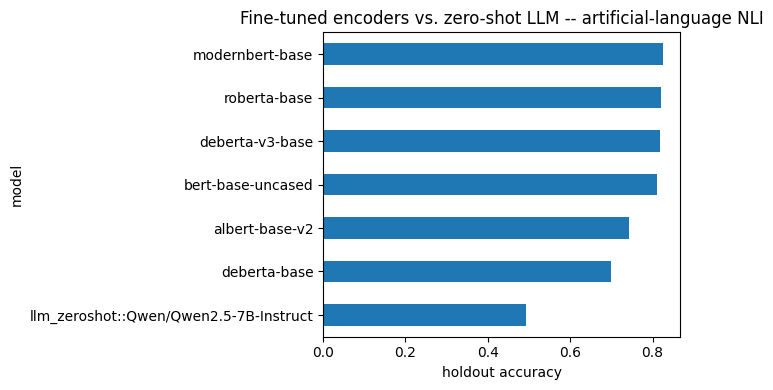

In [22]:
import matplotlib.pyplot as plt

ax = combined["holdout_accuracy"].plot(kind="barh", figsize=(7, 4))
ax.invert_yaxis()
ax.set_xlabel("holdout accuracy")
ax.set_title("Fine-tuned encoders vs. zero-shot LLM -- artificial-language NLI")
plt.tight_layout()
plt.savefig("holdout_accuracy_comparison.png", dpi=120)
plt.show()


In [23]:
metric_cols = ["holdout_accuracy", "identical_openclass_accuracy",
               "perturbation_consistency", "reversal_consistency"]
combined[metric_cols].style.background_gradient(cmap="Blues", axis=0).format("{:.3f}")


,holdout_accuracy,identical_openclass_accuracy,perturbation_consistency,reversal_consistency
model,,,,
modernbert-base,0.826,0.963,0.321,0.833
roberta-base,0.820,1.000,0.264,1.000
deberta-v3-base,0.818,1.000,0.250,1.000
bert-base-uncased,0.811,1.000,0.275,0.963
albert-base-v2,0.742,0.988,0.292,0.846
deberta-base,0.699,0.000,0.000,1.000
llm_zeroshot::Qwen/Qwen2.5-7B-Instruct,0.493,0.087,0.286,0.708


## Notes

- Dataset scale/balance knobs are the constants at the top of `generate.py` (`KNOWN_BLOCKS`, `TRAIN_PER_BLOCK`, `MIN_TRAIN_PER_CLASS`, `MAX_TRAIN_PER_CLASS`).
- `deberta-base` is kept in `MODEL_CHECKPOINTS` on purpose -- it has a documented tendency to collapse toward the majority relation ('#') on this task. Its row in `combined_results` and its predicted-label distributions printed during training are the evidence for that, not a reason to drop it.
- `deberta-v3-base` and `albert-base-v2` are the two extra candidates added to see whether a different pretraining recipe does better on the larger, rebalanced data.
- The LLM row (`llm_zeroshot::...`) is zero-shot/few-shot only, never fine-tuned -- treat its numbers as a different kind of baseline (in-context pattern-matching over a handful of examples) rather than an apples-to-apples comparison with the encoders.
- `perturbation_consistency` / `reversal_consistency` (conditioned on the original item being correct, per Goodwin et al. sections 7.1/7.3) are the actual systematicity numbers -- that's what should anchor the paper's argument, not raw holdout accuracy.
